In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!cp -r /content/drive/MyDrive/data /content/

# SHAP Feature Importance & MOA-stratified Analysis

## Overview

This notebook builds on the fitted models from notebook 02 and performs
two complementary analyses:

### Part A — MOA Annotation
Annotate CTRPv2 compounds with mechanism of action (MOA) via the ChEMBL API,
then collapse the raw MOA strings into coarse classes for per-class comparison.

### Part B — SHAP Analysis
For each modeled compound, compute SHAP values using the fitted models
from notebook 02. Two levels:

1. **Per-gene SHAP** — which specific genes/proteins drive predictions?
2. **Per-layer SHAP** — which omics layer (expression / mutations / CNV)
   is most informative per drug class?

### Part C — MOA-stratified Comparison
Group compounds by MOA class and compare omics-layer importance profiles.
Export top-gene lists per MOA class as a furute input for KEGG/GO analisys.

## Key design decisions

- **Best model from notebook 02** is read from `shap_handover_recommendation.csv`
- **Default SHAP mode: `single_omics` per layer** — each layer has its own Ridge model,
  gene names are clean (no prefix). For cross-layer comparison, importance is
  normalized across layers: `layer_importance[layer] = sum(|SHAP|) / sum(all |SHAP|)`.
- **Also supports `early_fusion`** — single model, features prefixed `layer::gene`.
- **Explainer selection** (per model type):
  - `RidgeCV`, `ElasticNet`, `RidgeSelectK` → `shap.LinearExplainer`
  - `XGBoost`, `LightGBM` → `shap.TreeExplainer`
- **Fold averaging** — SHAP is computed for each of the 5 saved fold-models and
  averaged. Simpler than out-of-fold but appropriate for feature importance (not for
  prediction quality assessment).
- **Caching** — SHAP results saved to parquet; re-run is instant.

## 0. Setup

In [5]:
%pip install -q shap pandas numpy matplotlib seaborn pyarrow joblib requests tqdm

In [6]:
import os
import re
import time
import warnings
from pathlib import Path
from typing import Optional

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import requests
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

try:
    import shap
    print(f"shap {shap.__version__}")
except ImportError:
    raise ImportError("Install shap: %pip install shap")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

PROJECT_DIR = Path.cwd()

shap 0.52.0


In [7]:
DATA_DIR      = PROJECT_DIR / "data"
RAW_DIR       = DATA_DIR / "raw"
SHAP_DIR      = DATA_DIR / "shap_results"
SHAP_DIR.mkdir(parents=True, exist_ok=True)

print("Imports OK")
print(f"PROJECT_DIR: {PROJECT_DIR}")

Imports OK
PROJECT_DIR: /content


In [8]:
# Load handover from notebook 02
# Find the most recent results directory (any LAYER_CONFIG config)
def find_results_dir(data_dir: Path) -> Path:
    """Find the most recent model_results directory."""
    handover_files = list(data_dir.glob("model_results_*/shap_handover_recommendation.csv"))
    if not handover_files:
        raise FileNotFoundError(
            "No shap_handover_recommendation.csv found.\n"
            "Run notebook 02 first to train and save models."
        )
    # Prefer the one matching current LAYER_CONFIG if multiple exist
    handover_files.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return handover_files[0].parent

RESULTS_DIR = find_results_dir(DATA_DIR)
handover_path = RESULTS_DIR / "shap_handover_recommendation.csv"
handover = pd.read_csv(handover_path).iloc[0]

MODEL_DIR     = Path(handover["models_dir"])
PROCESSED_DIR = Path(handover["processed_dir"])
ACTIVE_LAYERS = [l.strip() for l in handover["active_layers"].split(",")]

BEST_MODEL_FAMILY = handover["model_family"]
BEST_STRATEGY     = handover["strategy"]
BEST_OMICS_LAYER  = handover["omics_layer"]
BEST_FEATURE_KEY  = handover["feature_key"]
N_SPLITS          = 5

print(f"RESULTS_DIR   : {RESULTS_DIR}")
print(f"MODEL_DIR     : {MODEL_DIR}")
print(f"PROCESSED_DIR : {PROCESSED_DIR}")
print(f"ACTIVE_LAYERS : {ACTIVE_LAYERS}")
print(f"\nBest config from notebook 02:")
print(f"  model_family : {BEST_MODEL_FAMILY}")
print(f"  strategy     : {BEST_STRATEGY}")
print(f"  omics_layer  : {BEST_OMICS_LAYER}")
print(f"  feature_key  : {BEST_FEATURE_KEY}")
print(f"  mean_pearson : {handover['mean_pearson']:.4f}")
print(f"  SHAP explainer: {handover['shap_explainer']}")

RESULTS_DIR   : /content/data/model_results_expr_mut_cnv
MODEL_DIR     : /content/data/model_results_expr_mut_cnv/fitted_models
PROCESSED_DIR : /content/data/processed_no_prot_no_methyl
ACTIVE_LAYERS : ['expr', 'mut', 'cnv']

Best config from notebook 02:
  model_family : XGBoost
  strategy     : early_fusion
  omics_layer  : multiomics
  feature_key  : early_fusion
  mean_pearson : 0.5708
  SHAP explainer: shap.TreeExplainer    (tree-based)


In [9]:
# SHAP configuration
# SHAP_MODE controls which models we use for computing SHAP values.
#
#   "single_omics" (default):
#       One model per layer per compound. Gene names are clean (no prefix).
#       Layer importance = sum(|SHAP|) per layer, normalized across layers.
#       Best for: per-gene analysis, max predictive accuracy per layer.
#
#   "early_fusion":
#       One model covering all layers, features prefixed "layer::gene".
#       Layer importance = sum(|SHAP|) of all features belonging to that layer.
#       Best for: cross-layer interaction analysis.
#
# Set to "best" to auto-select based on notebook notebook 02 handover.

SHAP_MODE = "best"   # "single_omics" | "early_fusion" | "best"

if SHAP_MODE == "best":
    SHAP_MODE = "early_fusion" if BEST_STRATEGY == "early_fusion" else "single_omics"

print(f"SHAP_MODE: {SHAP_MODE}")

N_BACKGROUND_SAMPLES = 100    # samples for LinearExplainer background
MAX_COMPOUNDS        = None   # None = all eligible
TOP_N_GENES_PER_MOA  = 30     # genes exported per MOA class for KEGG/GO

SHAP_MODE: early_fusion


## Part A — MOA Annotation

### A.1 Load CTRPv2 compound list

In [10]:
df_comp = pd.read_parquet(RAW_DIR / "ctrpv2_compounds.parquet")
print(f"CTRPv2 compounds: {len(df_comp)}")
print(f"Columns: {df_comp.columns.tolist()}")
n_with_chembl = df_comp["chembl_id"].notna().sum()
print(f"With ChEMBL ID: {n_with_chembl}/{len(df_comp)} ({n_with_chembl/len(df_comp):.0%})")
df_comp.head(3)

CTRPv2 compounds: 544
Columns: ['compound_id', 'compound', 'uid', 'smiles', 'inchikey', 'pubchem_cid', 'fda_status', 'chembl_id']
With ChEMBL ID: 192/544 (35%)


,compound_id,compound,uid,smiles,inchikey,pubchem_cid,fda_status,chembl_id
0,109,(-)-Epigallocatechin gallate,PDBC01792,,,65064,NA,None
1,113,(-)-Parthenolide,PDBC00136,,,5420804,NA,CHEMBL465158
2,4856,"1,9-Pyrazoloanthrone",PDBC00191,,,8515,NA,CHEMBL7064


### A.2 Fetch MOA from ChEMBL API

ChEMBL `/mechanism` endpoint returns the mechanism of action for each molecule.

We query by `molecule_chembl_id` and take the primary mechanism.

Results are cached to `data/raw/ctrpv2_moa_chembl.parquet`

In [11]:
CHEMBL_BASE = "https://www.ebi.ac.uk/chembl/api/data"

def get_chembl_moa(chembl_id: str, retries: int = 3) -> dict:
    """
    Query ChEMBL for mechanism of action.
    Returns dict with keys: mechanism_of_action, action_type, target_chembl_id.
    Returns {} if not found.
    """
    if pd.isna(chembl_id) or not str(chembl_id).strip():
        return {}
    url = f"{CHEMBL_BASE}/mechanism.json"
    params = {"molecule_chembl_id": str(chembl_id).strip(),
              "format": "json", "limit": 10}
    for attempt in range(retries):
        try:
            r = requests.get(url, params=params, timeout=20)
            r.raise_for_status()
            mechanisms = r.json().get("mechanisms", [])
            if not mechanisms:
                return {}
            m = mechanisms[0]
            return {
                "mechanism_of_action": m.get("mechanism_of_action"),
                "action_type":         m.get("action_type"),
                "target_chembl_id":    m.get("target_chembl_id"),
            }
        except requests.RequestException:
            time.sleep(1.5 * (attempt + 1))
    return {}

In [12]:
moa_cache_path = RAW_DIR / "ctrpv2_moa_chembl.parquet"

if moa_cache_path.exists():
    df_moa_raw = pd.read_parquet(moa_cache_path)
    print(f"Loaded from cache: {moa_cache_path.name} ({len(df_moa_raw)} rows)")
else:
    records = []
    for _, row in tqdm(df_comp.iterrows(), total=len(df_comp), desc="ChEMBL MOA"):
        result = get_chembl_moa(row.get("chembl_id"))
        records.append({
            "compound":            row["compound"],
            "compound_id":         row["compound_id"],
            "chembl_id":           row.get("chembl_id"),
            "mechanism_of_action": result.get("mechanism_of_action"),
            "action_type":         result.get("action_type"),
            "target_chembl_id":    result.get("target_chembl_id"),
        })
        time.sleep(0.2)

    df_moa_raw = pd.DataFrame(records)
    df_moa_raw.to_parquet(moa_cache_path, index=False)
    print(f"Saved: {moa_cache_path.name} ({len(df_moa_raw)} rows)")

n_annotated = df_moa_raw["mechanism_of_action"].notna().sum()
print(f"Annotated: {n_annotated}/{len(df_moa_raw)} "
      f"({n_annotated/len(df_moa_raw):.0%})")

print("\nTop raw MOA strings (most frequent):")
print(df_moa_raw["mechanism_of_action"].value_counts().head(15).to_string())

Loaded from cache: ctrpv2_moa_chembl.parquet (544 rows)
Annotated: 73/544 (13%)

Top raw MOA strings (most frequent):
mechanism_of_action
DNA inhibitor                                              7
PI3-kinase class I inhibitor                               3
Tyrosine-protein kinase ABL inhibitor                      3
Epidermal growth factor receptor erbB1 inhibitor           3
Serine/threonine-protein kinase PLK1 inhibitor             2
Histone deacetylase inhibitor                              2
DNA (cytosine-5)-methyltransferase 3A inhibitor            2
Serine/threonine-protein kinase mTOR inhibitor             2
26S proteasome inhibitor                                   2
DNA topoisomerase I inhibitor                              2
FK506-binding protein 1A inhibitor                         2
Macrophage colony stimulating factor receptor inhibitor    2
PARP 1, 2 and 3 inhibitor                                  2
HMG-CoA reductase inhibitor                                2
Tyrosine

### A.3 Map to coarse MOA classes

Raw ChEMBL MOA strings are very specific (e.g. "EGFR inhibitor", "PARP inhibitor").

We collapse them into ~8 interpretable classes for per-class SHAP comparison.

Compounds without a ChEMBL annotation -> `"Other/Unknown"`.

In [13]:
# Keyword -> coarse MOA class. First match wins.
MOA_RULES = [
    # DNA damage / replication
    ("PARP",            "DNA damage/repair"),
    ("topoisomerase",   "DNA damage/repair"),
    ("alkylat",         "DNA damage/repair"),
    ("intercalat",      "DNA damage/repair"),
    ("DNA",             "DNA damage/repair"),
    # Kinase inhibitors
    ("kinase",          "Kinase inhibitor"),
    ("EGFR",            "Kinase inhibitor"),
    ("VEGFR",           "Kinase inhibitor"),
    ("mTOR",            "Kinase inhibitor"),
    ("CDK",             "Kinase inhibitor"),
    ("ABL",             "Kinase inhibitor"),
    ("BRAF",            "Kinase inhibitor"),
    ("MEK",             "Kinase inhibitor"),
    ("PI3K",            "Kinase inhibitor"),
    ("AKT",             "Kinase inhibitor"),
    ("RAF",             "Kinase inhibitor"),
    ("ERK",             "Kinase inhibitor"),
    # Cytoskeleton / cell cycle
    ("tubulin",         "Cytoskeleton/cell cycle"),
    ("microtubule",     "Cytoskeleton/cell cycle"),
    ("Aurora",          "Cytoskeleton/cell cycle"),
    ("PLK",             "Cytoskeleton/cell cycle"),
    ("kinesin",         "Cytoskeleton/cell cycle"),
    # Epigenetic
    ("histone",         "Epigenetic"),
    ("HDAC",            "Epigenetic"),
    ("methyltransfer",  "Epigenetic"),
    ("bromodomain",     "Epigenetic"),
    ("BET",             "Epigenetic"),
    ("EZH2",            "Epigenetic"),
    # Proteasome / protein homeostasis
    ("proteasome",      "Proteasome/protein"),
    ("HSP",             "Proteasome/protein"),
    ("MDM2",            "Proteasome/protein"),
    ("ubiquitin",       "Proteasome/protein"),
    # Receptor / hormonal
    ("receptor",        "Receptor"),
    ("estrogen",        "Receptor"),
    ("androgen",        "Receptor"),
    ("GPCR",            "Receptor"),
    # Metabolic / antimetabolite
    ("DHFR",            "Metabolic"),
    ("thymidylate",     "Metabolic"),
    ("metabol",         "Metabolic"),
    ("nucleoside",      "Metabolic"),
    ("purine",          "Metabolic"),
    ("pyrimidine",      "Metabolic"),
]

In [14]:
def assign_moa_class(moa_str: str) -> str:
    if pd.isna(moa_str):
        return "Other/Unknown"
    low = moa_str.lower()
    for keyword, cls in MOA_RULES:
        if keyword.lower() in low:
            return cls
    return "Other/Unknown"

In [15]:
df_moa_raw["moa_class"] = df_moa_raw["mechanism_of_action"].apply(assign_moa_class)

class_counts = df_moa_raw["moa_class"].value_counts()
print("MOA class distribution:")
print(class_counts.to_string())

MOA class distribution:
moa_class
Other/Unknown              486
Kinase inhibitor            19
Receptor                    15
DNA damage/repair           14
Proteasome/protein           4
Epigenetic                   3
Cytoskeleton/cell cycle      2
Metabolic                    1


In [16]:
# Merge tiny classes (< MIN_CLASS_SIZE compounds) into Other/Unknown
MIN_CLASS_SIZE = 5
small = class_counts[class_counts < MIN_CLASS_SIZE].index.tolist()
if small:
    print(f"Merging small classes into 'Other/Unknown': {small}")
    df_moa_raw.loc[df_moa_raw["moa_class"].isin(small), "moa_class"] = "Other/Unknown"

# Final MOA table
df_moa = df_moa_raw[["compound", "compound_id", "chembl_id",
                       "mechanism_of_action", "action_type",
                       "moa_class"]].copy()
moa_save_path = SHAP_DIR / "compound_moa.parquet"
df_moa.to_parquet(moa_save_path, index=False)
print(f"Saved: {moa_save_path.name} ({len(df_moa)} compounds)")

Merging small classes into 'Other/Unknown': ['Proteasome/protein', 'Epigenetic', 'Cytoskeleton/cell cycle', 'Metabolic']
Saved: compound_moa.parquet (544 compounds)


In [17]:
# Build lookup dict used throughout the rest of the notebook
moa_map = df_moa.set_index("compound")["moa_class"].to_dict()

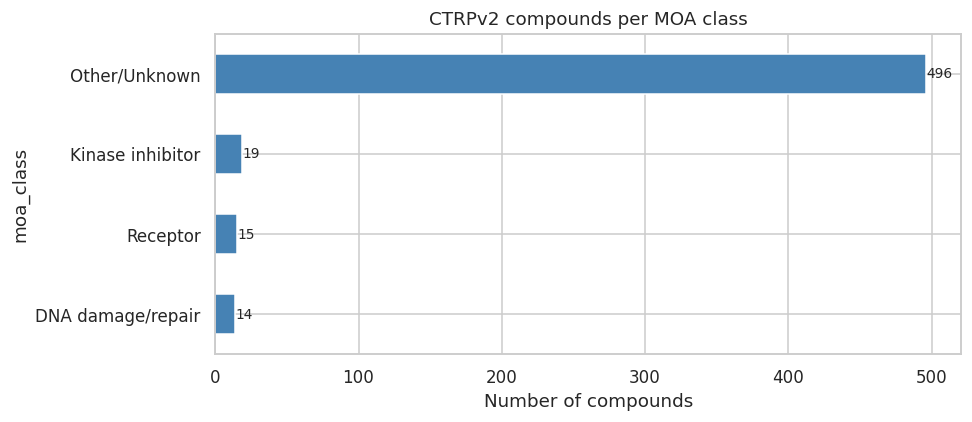


MOA classes used in analysis: ['DNA damage/repair', 'Kinase inhibitor', 'Other/Unknown', 'Receptor']


In [18]:
# Visualize MOA distribution
fig, ax = plt.subplots(figsize=(9, 4))
class_counts_final = df_moa["moa_class"].value_counts()
class_counts_final.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Number of compounds")
ax.set_title("CTRPv2 compounds per MOA class")
for i, v in enumerate(class_counts_final.sort_values()):
    ax.text(v + 0.3, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.savefig(SHAP_DIR / "moa_class_distribution.png", dpi=150)
plt.show()

print(f"\nMOA classes used in analysis: "
      f"{sorted(class_counts_final[class_counts_final >= MIN_CLASS_SIZE].index.tolist())}")

## Part B — SHAP Analysis

### B.1 Reconstruct feature matrices

We rebuild the **exact same feature sets** as notebook 02 so that feature
names match what the saved models were trained on.

Key parameters that must match notebook 02:
- `FEATURE_SELECTION_K = 1000` (quick mode) or `None` (full)
- Variance-based selection (same order of features)

In [19]:
# Load omics layers (already z-scored from data prep)
LAYER_FILE_NAMES = {
    "expr": "expression", "mut": "mutations",
    "cnv": "cnv", "meth": "methylation", "prot": "proteomics",
}

In [20]:
omics = {}
for key in ACTIVE_LAYERS:
    fname = LAYER_FILE_NAMES[key]
    p = PROCESSED_DIR / f"{fname}.parquet"
    df = pd.read_parquet(p)
    if "ModelID" in df.columns:
        df = df.set_index("ModelID")
    df = df.drop(columns=[c for c in df.columns if str(c).startswith("Unnamed")],
                 errors="ignore")
    omics[key] = df
    print(f"  {key:<5}: {df.shape}")

drug_response = pd.read_parquet(PROCESSED_DIR / "drug_response.parquet")
if "ModelID" in drug_response.columns:
    drug_response = drug_response.set_index("ModelID")

  expr : (574, 4999)
  mut  : (574, 1000)
  cnv  : (574, 4999)


In [21]:
# Common cells
common_ids = sorted(
    set.intersection(*(set(df.index) for df in omics.values()),
                     set(drug_response.index))
)
omics = {k: df.loc[common_ids].sort_index().fillna(0.0).astype(np.float32)
         for k, df in omics.items()}
drug_response = drug_response.loc[common_ids].sort_index().astype(np.float32)
print(f"\nCommon cell lines: {len(common_ids)}")


Common cell lines: 574


In [22]:
# Variance-based feature selection
def select_features_by_variance(df: pd.DataFrame,
                                 k: Optional[int] = None) -> pd.DataFrame:
    if k is None or k >= df.shape[1]:
        return df.copy()
    variances = df.var(axis=0, ddof=1).fillna(0.0)
    return df.loc[:, variances.sort_values(ascending=False).head(k).index].copy()

# FEATURE_SELECTION_K: set to match notebook 02
# quick mode (RUN_FULL_MODELING=False) -> 1000; full -> None
FEATURE_SELECTION_K = 1000

omics_for_modeling = {k: select_features_by_variance(df, FEATURE_SELECTION_K)
                      for k, df in omics.items()}

print("Feature sets for SHAP (must match notebook 02):")
for k, df in omics_for_modeling.items():
    print(f"  {k:<5}: {df.shape}")

Feature sets for SHAP (must match notebook 02):
  expr : (574, 1000)
  mut  : (574, 1000)
  cnv  : (574, 1000)


In [23]:
# Build feature_sets dict
feature_sets: dict[str, pd.DataFrame] = {}

# Single-omics sets (no prefix, clean gene names)
for layer in ACTIVE_LAYERS:
    feature_sets[layer] = omics_for_modeling[layer]

# Early fusion (prefix: "layer::gene")
early_fusion_parts = [
    omics_for_modeling[n].rename(columns=lambda c, n=n: f"{n}::{c}")
    for n in ACTIVE_LAYERS
]
feature_sets["early_fusion"] = pd.concat(early_fusion_parts, axis=1)

print("\nFeature sets available for SHAP:")
for name, df in feature_sets.items():
    print(f"  {name:<16}: {df.shape[1]:>6} features")

# For "early_fusion" mode the feature-to-layer mapping is derived from prefix
def feature_to_layer(feature_name: str,
                     layer_in_single_mode: Optional[str] = None) -> str:
    """Return the omics layer name for a given feature."""
    if "::" in str(feature_name):
        return str(feature_name).split("::", 1)[0]
    return layer_in_single_mode or "unknown"


Feature sets available for SHAP:
  expr            :   1000 features
  mut             :   1000 features
  cnv             :   1000 features
  early_fusion    :   3000 features


### B.2 Model loading helpers

In [24]:
def safe_compound_name(compound: str) -> str:
    """Reproduce notebook 02 _model_save_path sanitization."""
    return (compound.replace(" ", "_")
                    .replace("/", "-")
                    .replace("(", "")
                    .replace(")", ""))

In [25]:
def load_fold_model(model_family: str,
                    compound: str,
                    strategy: str,
                    fold_id: int) -> Optional[object]:
    """Load a single saved fold-model. Returns None if not found."""
    safe = safe_compound_name(compound)
    path = MODEL_DIR / f"{model_family}__{safe}__{strategy}__fold{fold_id}.pkl"
    if not path.exists():
        return None
    return joblib.load(path)

In [26]:
def list_saved_models(model_family: str,
                      strategy: str) -> list[str]:
    """List compounds that have at least one saved model for this config."""
    pattern = f"{model_family}__*__{strategy}__fold1.pkl"
    paths = list(MODEL_DIR.glob(pattern))
    compounds = []
    for p in paths:
        # Reverse-engineer compound name from filename
        safe = p.stem.split(f"{model_family}__")[1].split(f"__{strategy}")[0]
        compounds.append(safe)
    return compounds

In [27]:
available = list_saved_models(BEST_MODEL_FAMILY, BEST_STRATEGY)
print(f"Saved models found for ({BEST_MODEL_FAMILY}, {BEST_STRATEGY}): "
      f"{len(available)} compounds")
if not available:
    print("\nWARNING: No models found. Check that notebook 02 ran with "
          "TOP_CONFIGS=None (save all) or that the best config was in TOP_CONFIGS.")

Saved models found for (XGBoost, early_fusion): 12 compounds


### B.3 SHAP computation helpers

Selects the right explainer automatically based on model type.

In [28]:
def _get_shap_values_linear(model, X_train_bg: np.ndarray,
                             X_explain: np.ndarray,
                             n_features_in: int) -> np.ndarray:
    """
    Compute SHAP values for linear sklearn Pipeline
    (RidgeCV, ElasticNetCV, RidgeSelectK).

    For RidgeSelectK: SelectKBest reduces the feature space.
    We apply the pre-processing steps manually, compute SHAP in the
    reduced space, then expand back to the full feature space using
    the SelectKBest mask.
    """
    # Check if pipeline has a feature selector
    has_selector = (hasattr(model, "named_steps")
                    and "selectkbest" in model.named_steps)

    if has_selector:
        # Transform data through pre-processing steps (all except final estimator)
        transform_steps = model[:-1]
        X_bg_t  = transform_steps.transform(X_train_bg)
        X_exp_t = transform_steps.transform(X_explain)
        estimator = model[-1]   # fitted RidgeCV
    else:
        # No selector - data passes straight to the estimator
        if hasattr(model, "named_steps"):
            estimator = model.named_steps[list(model.named_steps)[-1]]
            # Apply any scaler if present
            if len(model.named_steps) > 1:
                X_bg_t  = model[:-1].transform(X_train_bg)
                X_exp_t = model[:-1].transform(X_explain)
            else:
                X_bg_t, X_exp_t = X_train_bg, X_explain
        else:
            estimator = model
            X_bg_t, X_exp_t = X_train_bg, X_explain

    masker = shap.maskers.Independent(X_bg_t,
                                      max_samples=min(N_BACKGROUND_SAMPLES,
                                                      len(X_bg_t)))
    explainer = shap.LinearExplainer(estimator, masker)
    shap_reduced = explainer.shap_values(X_exp_t)   # (n_samples, n_selected)

    if not has_selector:
        return shap_reduced   # already full-size

    # Expand back: SelectKBest mask -> full feature space
    mask = model.named_steps["selectkbest"].get_support()
    shap_full = np.zeros((shap_reduced.shape[0], n_features_in), dtype=float)
    shap_full[:, mask] = shap_reduced
    return shap_full

In [29]:
def compute_shap_values(model,
                        X_train: np.ndarray,
                        X_explain: np.ndarray,
                        n_features_in: int) -> np.ndarray:
    """
    Universal SHAP dispatcher.
    Returns np.ndarray of shape (n_samples, n_features_in).
    """
    # Identify the final estimator type
    if hasattr(model, "named_steps"):
        estimator = list(model.named_steps.values())[-1]
    else:
        estimator = model
    etype = type(estimator).__name__

    if etype in {"RidgeCV", "Ridge", "ElasticNetCV", "ElasticNet",
                 "Lasso", "LassoCV", "LinearRegression"}:
        return _get_shap_values_linear(model, X_train, X_explain, n_features_in)

    elif etype in {"XGBRegressor", "LGBMRegressor",
                   "RandomForestRegressor", "GradientBoostingRegressor"}:
        explainer = shap.TreeExplainer(estimator)
        sv = explainer.shap_values(X_explain)
        return np.array(sv)

    else:
        warnings.warn(f"Unknown estimator type '{etype}'. Using shap.Explainer (slow).")
        bg_df = pd.DataFrame(X_train[:N_BACKGROUND_SAMPLES])
        explainer = shap.Explainer(model, bg_df)
        return explainer(pd.DataFrame(X_explain)).values

### B.4 Main SHAP loop

For each compound × fold model: compute SHAP, average across folds.

In [30]:
shap_cache_genes  = SHAP_DIR / "shap_per_gene_per_compound.parquet"
shap_cache_layers = SHAP_DIR / "shap_per_layer_per_compound.parquet"

if shap_cache_genes.exists() and shap_cache_layers.exists():
    df_shap_genes  = pd.read_parquet(shap_cache_genes)
    df_shap_layers = pd.read_parquet(shap_cache_layers)
    print(f"Loaded from cache:")
    print(f"  {shap_cache_genes.name}:  {df_shap_genes.shape}")
    print(f"  {shap_cache_layers.name}: {df_shap_layers.shape}")
else:
    # Determine feature set for SHAP
    if SHAP_MODE == "early_fusion":
        shap_feature_key = "early_fusion"
        shap_strategy    = "early_fusion"
    else:
        # single_omics: we compute separately per layer, then combine
        shap_feature_key = BEST_FEATURE_KEY   # e.g. "expr"
        shap_strategy    = "single_omics"

    # List compounds with saved models
    eligible_path = RESULTS_DIR / "eligible_compounds.csv"
    if eligible_path.exists():
        modeling_compounds = pd.read_csv(eligible_path)["compound"].tolist()
    else:
        modeling_compounds = list_saved_models(BEST_MODEL_FAMILY, shap_strategy)
    if MAX_COMPOUNDS:
        modeling_compounds = modeling_compounds[:MAX_COMPOUNDS]

    print(f"Computing SHAP for {len(modeling_compounds)} compounds "
          f"(mode={SHAP_MODE}, model={BEST_MODEL_FAMILY}, strategy={shap_strategy})")

    gene_records  = []   # mean |SHAP| per gene per compound
    layer_records = []   # normalized layer importance per compound
    failed        = []

    for compound in tqdm(modeling_compounds, desc="SHAP"):
        # y for this compound - needed to reconstruct fold splits
        if compound not in drug_response.columns:
            failed.append((compound, "not in drug_response"))
            continue
        y = drug_response[compound].dropna()
        valid_ids = y.index.to_numpy()
        if len(valid_ids) < 30:
            failed.append((compound, f"too few samples ({len(valid_ids)})"))
            continue

        if SHAP_MODE == "single_omics":
            # Compute SHAP per layer, then aggregate across layers
            layer_shap_sums = {}   # layer -> summed mean |SHAP|
            all_gene_shap   = {}   # gene -> mean |SHAP| from its layer's model

            for layer in ACTIVE_LAYERS:
                X_layer = feature_sets[layer]
                feature_names = X_layer.columns.to_numpy()
                n_feats = len(feature_names)

                # Accumulate SHAP across folds
                fold_shap_list = []
                for fold_id in range(1, N_SPLITS + 1):
                    model = load_fold_model(BEST_MODEL_FAMILY, compound,
                                            "single_omics", fold_id)
                    if model is None:
                        continue

                    # Reconstruct this fold's train/test split
                    from sklearn.model_selection import KFold
                    kf = KFold(n_splits=N_SPLITS, shuffle=True,
                               random_state=42)
                    splits = list(kf.split(valid_ids))
                    train_idx, test_idx = splits[fold_id - 1]
                    train_ids = valid_ids[train_idx]

                    X_tr = X_layer.loc[train_ids].to_numpy(dtype=np.float32)
                    X_all = X_layer.loc[valid_ids].to_numpy(dtype=np.float32)

                    try:
                        sv = compute_shap_values(model, X_tr, X_all, n_feats)
                        fold_shap_list.append(np.abs(sv).mean(axis=0))
                    except Exception as e:
                        warnings.warn(f"  {compound} {layer} fold{fold_id}: {e}")

                if not fold_shap_list:
                    continue

                mean_abs_shap = np.stack(fold_shap_list).mean(axis=0)

                # Store per-gene
                for gene, val in zip(feature_names, mean_abs_shap):
                    all_gene_shap[f"{layer}::{gene}"] = float(val)

                layer_shap_sums[layer] = float(mean_abs_shap.sum())

            if not layer_shap_sums:
                failed.append((compound, "no SHAP computed"))
                continue

            # Normalize layer importance to sum to 1
            total = sum(layer_shap_sums.values())
            layer_importance = {k: v / total if total > 0 else np.nan
                                for k, v in layer_shap_sums.items()}

        else:  # early_fusion
            X_ef = feature_sets["early_fusion"]
            feature_names = X_ef.columns.to_numpy()
            n_feats = len(feature_names)

            fold_shap_list = []
            for fold_id in range(1, N_SPLITS + 1):
                model = load_fold_model(BEST_MODEL_FAMILY, compound,
                                        "early_fusion", fold_id)
                if model is None:
                    continue

                from sklearn.model_selection import KFold
                kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
                splits = list(kf.split(valid_ids))
                train_idx, _ = splits[fold_id - 1]
                train_ids = valid_ids[train_idx]

                X_tr = X_ef.loc[train_ids].to_numpy(dtype=np.float32)
                X_all = X_ef.loc[valid_ids].to_numpy(dtype=np.float32)

                try:
                    sv = compute_shap_values(model, X_tr, X_all, n_feats)
                    fold_shap_list.append(np.abs(sv).mean(axis=0))
                except Exception as e:
                    warnings.warn(f"  {compound} ef fold{fold_id}: {e}")

            if not fold_shap_list:
                failed.append((compound, "no SHAP computed"))
                continue

            mean_abs_shap = np.stack(fold_shap_list).mean(axis=0)

            # Per-gene (keep full prefixed name)
            all_gene_shap = {fn: float(v)
                             for fn, v in zip(feature_names, mean_abs_shap)}

            # Per-layer: sum |SHAP| for all features belonging to that layer
            layer_shap_sums = {}
            for layer in ACTIVE_LAYERS:
                mask = np.array([feature_to_layer(fn) == layer
                                 for fn in feature_names])
                layer_shap_sums[layer] = float(mean_abs_shap[mask].sum())

            total = sum(layer_shap_sums.values())
            layer_importance = {k: v / total if total > 0 else np.nan
                                for k, v in layer_shap_sums.items()}

        gene_records.append({
            "compound":  compound,
            "moa_class": moa_map.get(compound, "Other/Unknown"),
            **all_gene_shap,
        })
        layer_records.append({
            "compound":  compound,
            "moa_class": moa_map.get(compound, "Other/Unknown"),
            **layer_importance,
        })

    if failed:
        print(f"\nFailed: {len(failed)}")
        for c, reason in failed[:10]:
            print(f"  {c}: {reason}")

    df_shap_genes  = pd.DataFrame(gene_records).set_index("compound")
    df_shap_layers = pd.DataFrame(layer_records).set_index("compound")

    df_shap_genes.to_parquet(shap_cache_genes)
    df_shap_layers.to_parquet(shap_cache_layers)
    print(f"\nSaved:")
    print(f"  {shap_cache_genes.name}:  {df_shap_genes.shape}")
    print(f"  {shap_cache_layers.name}: {df_shap_layers.shape}")

Computing SHAP for 426 compounds (mode=early_fusion, model=XGBoost, strategy=early_fusion)


SHAP:   0%|          | 0/426 [00:00<?, ?it/s]


Failed: 415
  docetaxel:tanespimycin (2:1 mol/mol): no SHAP computed
  ML210: no SHAP computed
  Parbendazole: no SHAP computed
  navitoclax:gemcitabine (1:1 mol/mol): no SHAP computed
  Paclitaxel: no SHAP computed
  Methotrexate: no SHAP computed
  tanespimycin:gemcitabine (1:1 mol/mol): no SHAP computed
  Daporinad: no SHAP computed
  Ouabain: no SHAP computed
  Dasatinib: no SHAP computed

Saved:
  shap_per_gene_per_compound.parquet:  (11, 3001)
  shap_per_layer_per_compound.parquet: (11, 4)


In [31]:
print(f"\nLayer importance summary (mean across all compounds):")
layer_cols = [c for c in df_shap_layers.columns if c != "moa_class"]
print(df_shap_layers[layer_cols].mean().round(3).to_string())


Layer importance summary (mean across all compounds):
expr    0.787
mut     0.004
cnv     0.209


## Part C - MOA-stratified Analysis

### C.1 Layer importance per MOA class

In [32]:
# Mean normalised layer importance per MOA class
moa_layer_df = (
    df_shap_layers.groupby("moa_class")[layer_cols]
    .mean()
    .round(3)
)
print("Mean normalised layer importance per MOA class:")
display(moa_layer_df)

moa_layer_df.to_csv(SHAP_DIR / "moa_layer_importance.csv")

Mean normalised layer importance per MOA class:


,expr,mut,cnv
moa_class,,,
Kinase inhibitor,0.837,0.004,0.159
Other/Unknown,0.782,0.004,0.214


### C.2 Heatmap — omics layer importance × MOA class

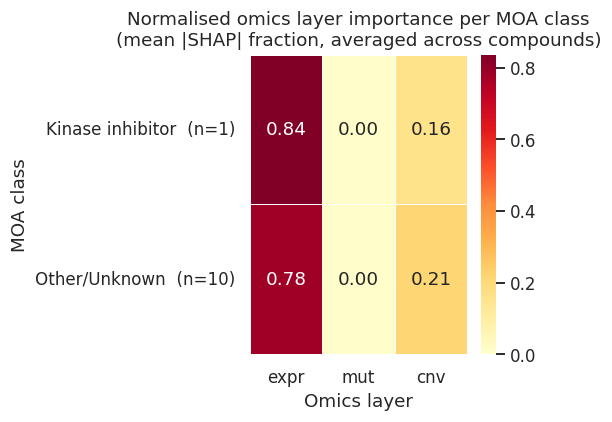

In [33]:
# Number of compounds per class (for annotation)
class_sizes = df_shap_layers.groupby("moa_class").size().rename("n_compounds")

fig, ax = plt.subplots(figsize=(max(5, len(layer_cols) * 1.4),
                                 max(4, len(moa_layer_df) * 0.55)))
im = sns.heatmap(
    moa_layer_df,
    annot=True, fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    vmin=0,
)
# Add sample sizes to y-axis labels
new_labels = [
    f"{idx}  (n={class_sizes.get(idx, '?')})"
    for idx in moa_layer_df.index
]
ax.set_yticklabels(new_labels, rotation=0)
ax.set_xlabel("Omics layer", fontsize=12)
ax.set_ylabel("MOA class", fontsize=12)
ax.set_title("Normalised omics layer importance per MOA class\n"
             "(mean |SHAP| fraction, averaged across compounds)", fontsize=12)
plt.tight_layout()
plt.savefig(SHAP_DIR / "moa_layer_importance_heatmap.png", dpi=150)
plt.show()

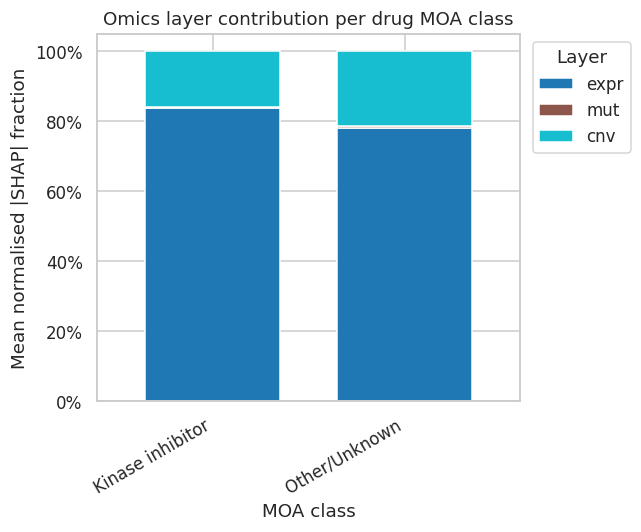

In [34]:
# Bar chart version (stacked)
fig, ax = plt.subplots(figsize=(max(6, len(moa_layer_df) * 0.8), 5))
moa_layer_df.plot(
    kind="bar", stacked=True, ax=ax,
    colormap="tab10", width=0.7,
)
ax.set_xlabel("MOA class")
ax.set_ylabel("Mean normalised |SHAP| fraction")
ax.set_title("Omics layer contribution per drug MOA class")
ax.legend(title="Layer", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(SHAP_DIR / "moa_layer_importance_barplot.png", dpi=150)
plt.show()

### C.3 Top genes per MOA class

For each MOA class, find the top-N genes by mean |SHAP| across all compounds in that class. These gene lists are the direct input to KEGG/GO analysis.

In [35]:
gene_cols = [c for c in df_shap_genes.columns if c != "moa_class"]

def top_genes_for_class(moa_class: str,
                         df_genes: pd.DataFrame,
                         df_layers: pd.DataFrame,
                         top_n: int = TOP_N_GENES_PER_MOA) -> pd.DataFrame:
    """
    For a MOA class, return top-N genes by mean |SHAP|, with layer annotation.
    Gene names in single_omics mode are prefixed: "expr::TP53".
    We strip the prefix for the export (clean gene name for enrichment tools).
    """
    compounds_in_class = df_layers[df_layers["moa_class"] == moa_class].index
    if len(compounds_in_class) == 0:
        return pd.DataFrame()

    class_shap = (df_genes
                  .loc[df_genes.index.isin(compounds_in_class), gene_cols]
                  .mean(axis=0)
                  .dropna()
                  .sort_values(ascending=False)
                  .head(top_n))

    result = pd.DataFrame({
        "feature":        class_shap.index,
        "mean_abs_shap":  class_shap.values,
    })
    # Extract clean gene name and layer
    result["omics_layer"] = result["feature"].apply(
        lambda f: f.split("::", 1)[0] if "::" in f else "unknown"
    )
    result["gene_name"] = result["feature"].apply(
        lambda f: f.split("::", 1)[1] if "::" in f else f
    )
    result["n_compounds_in_class"] = len(compounds_in_class)
    return result[["gene_name", "omics_layer", "mean_abs_shap",
                   "n_compounds_in_class"]]

In [36]:
# Compute top genes per MOA class
moa_classes = sorted(df_shap_layers["moa_class"].unique())
moa_top_genes: dict[str, pd.DataFrame] = {}

print(f"Top {TOP_N_GENES_PER_MOA} genes per MOA class:")
for moa_class in moa_classes:
    top = top_genes_for_class(moa_class, df_shap_genes, df_shap_layers)
    moa_top_genes[moa_class] = top
    n_compounds = (df_shap_layers["moa_class"] == moa_class).sum()
    print(f"\n[{moa_class}] — {n_compounds} compounds")
    print(top.head(10).to_string(index=False))

# Save CSV per class (input for KEGG/GO)
genes_dir = SHAP_DIR / "top_genes_per_moa"
genes_dir.mkdir(exist_ok=True)

for moa_class, df_genes_cls in moa_top_genes.items():
    fname = re.sub(r"[^a-zA-Z0-9_]", "_", moa_class) + ".csv"
    df_genes_cls.to_csv(genes_dir / fname, index=False)

print(f"\nSaved {len(moa_top_genes)} gene lists to: {genes_dir}")

Top 30 genes per MOA class:

[Kinase inhibitor] — 1 compounds
gene_name omics_layer  mean_abs_shap  n_compounds_in_class
  S100A16        expr       0.015193                     1
   PKD1L2        expr       0.015074                     1
   TM4SF1        expr       0.013549                     1
   ABLIM3        expr       0.012920                     1
     GLMP        expr       0.006111                     1
    WASF1        expr       0.004886                     1
     CTSD        expr       0.004386                     1
     RTF2         cnv       0.004237                     1
     SOD3        expr       0.003554                     1
     AHSP         cnv       0.003511                     1

[Other/Unknown] — 10 compounds
gene_name omics_layer  mean_abs_shap  n_compounds_in_class
   PKD1L2        expr       0.007680                    10
    IKZF1        expr       0.004953                    10
  S100A16        expr       0.004187                    10
   PTPN21        expr

In [37]:
# Summary gene table - all MOA classes together
all_top_genes = pd.concat(
    [df_g.assign(moa_class=cls) for cls, df_g in moa_top_genes.items()],
    ignore_index=True,
)
all_top_genes.to_csv(SHAP_DIR / "all_top_genes_by_moa.csv", index=False)
print(f"Combined table: {SHAP_DIR / 'all_top_genes_by_moa.csv'}")
all_top_genes.head(15)

Combined table: /content/data/shap_results/all_top_genes_by_moa.csv


,gene_name,omics_layer,mean_abs_shap,n_compounds_in_class,moa_class
0,S100A16,expr,0.015193,1,Kinase inhibitor
1,PKD1L2,expr,0.015074,1,Kinase inhibitor
2,TM4SF1,expr,0.013549,1,Kinase inhibitor
3,ABLIM3,expr,0.012920,1,Kinase inhibitor
4,GLMP,expr,0.006111,1,Kinase inhibitor
5,WASF1,expr,0.004886,1,Kinase inhibitor
6,CTSD,expr,0.004386,1,Kinase inhibitor
7,RTF2,cnv,0.004237,1,Kinase inhibitor
8,SOD3,expr,0.003554,1,Kinase inhibitor
9,AHSP,cnv,0.003511,1,Kinase inhibitor


### C.4 Top-gene bar chart per MOA class

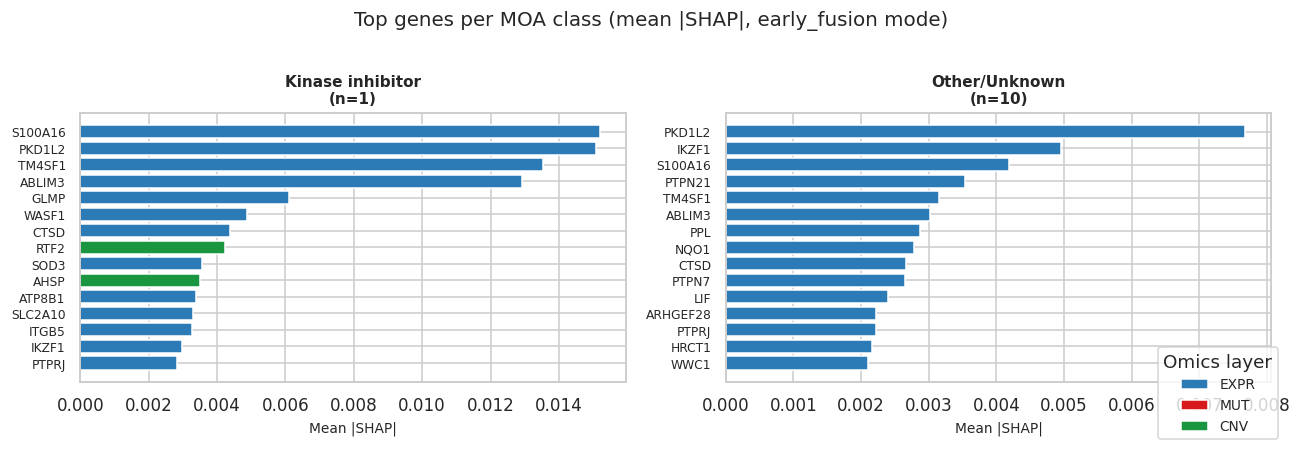

In [38]:
# One subplot per MOA class (top 15 genes)
n_classes = len(moa_classes)
n_cols_plot = min(3, n_classes)
n_rows_plot = (n_classes + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                          figsize=(6 * n_cols_plot, 4 * n_rows_plot))
axes_flat = np.array(axes).flatten() if n_classes > 1 else [axes]

LAYER_COLORS = {
    "expr": "#2c7bb6", "mut": "#d7191c",
    "cnv":  "#1a9641", "meth": "#fdae61", "prot": "#756bb1",
    "unknown": "#bdbdbd",
}

for ax, moa_class in zip(axes_flat, moa_classes):
    top = moa_top_genes[moa_class].head(15)
    if top.empty:
        ax.axis("off")
        continue
    colors = [LAYER_COLORS.get(l, "#bdbdbd") for l in top["omics_layer"]]
    bars = ax.barh(top["gene_name"][::-1],
                   top["mean_abs_shap"][::-1],
                   color=colors[::-1])
    ax.set_xlabel("Mean |SHAP|", fontsize=9)
    n_comp = top["n_compounds_in_class"].iloc[0]
    ax.set_title(f"{moa_class}\n(n={n_comp})", fontsize=10, fontweight="bold")
    ax.tick_params(axis="y", labelsize=8)

# Turn off unused axes
for ax in axes_flat[len(moa_classes):]:
    ax.axis("off")

# Legend for layers
handles = [plt.Rectangle((0, 0), 1, 1, fc=LAYER_COLORS.get(l, "#bdbdbd"),
                           label=l.upper())
           for l in ACTIVE_LAYERS]
fig.legend(handles=handles, title="Omics layer",
           loc="lower right", bbox_to_anchor=(0.98, 0.02), fontsize=9)

plt.suptitle(f"Top genes per MOA class (mean |SHAP|, {SHAP_MODE} mode)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(SHAP_DIR / "top_genes_per_moa_class.png",
            dpi=150, bbox_inches="tight")
plt.show()

### C.5 SHAP summary plot for one compound

Visualize raw SHAP values (direction + magnitude) for the top-scoring compound in the most populous MOA class.

In [39]:
# Pick a compound: top Pearson in the most common non-Other MOA class
main_classes = [c for c in moa_classes if c != "Other/Unknown"]
if not main_classes:
    main_classes = moa_classes

In [40]:
# Find compound with highest layer-importance signal in a well-represented class
target_class = class_sizes[main_classes].idxmax()
compounds_in_target = df_shap_layers[
    df_shap_layers["moa_class"] == target_class
].index.tolist()

In [41]:
# Use first available compound with fold1 model
example_compound = None
for c in compounds_in_target:
    if load_fold_model(BEST_MODEL_FAMILY, c, BEST_STRATEGY, 1) is not None:
        example_compound = c
        break

Example compound: BI-2536  (MOA: Kinase inhibitor)


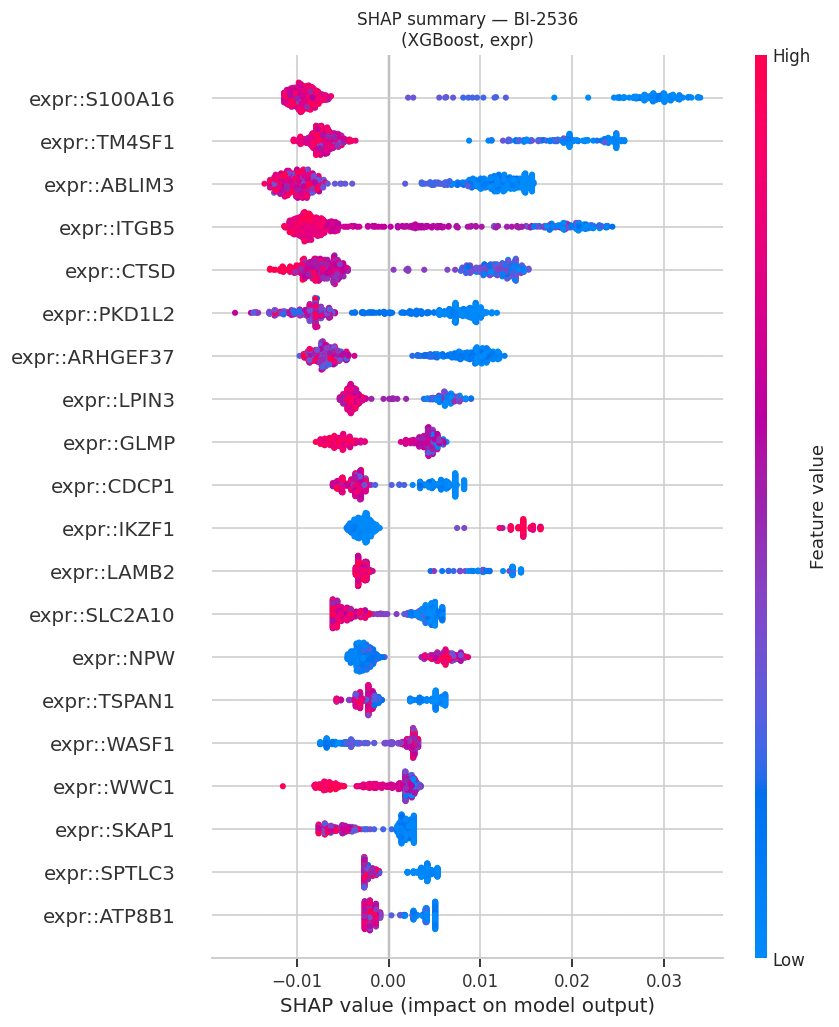

Summary plot saved.


In [43]:
if example_compound is None:
    print("No compound found for summary plot — skip.")
else:
    print(f"Example compound: {example_compound}  (MOA: {target_class})")
    if SHAP_MODE == "early_fusion":
        X_layer = feature_sets["early_fusion"]
    else:
        X_layer = feature_sets[BEST_FEATURE_KEY]

    feat_names = X_layer.columns.to_numpy()
    n_feats = len(feat_names)

    y_comp = drug_response[example_compound].dropna()
    valid_ids = y_comp.index.to_numpy()

    model_ex = load_fold_model(BEST_MODEL_FAMILY, example_compound,
                                BEST_STRATEGY, 1)
    if model_ex is not None:
        from sklearn.model_selection import KFold
        kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
        splits = list(kf.split(valid_ids))
        train_idx, _ = splits[0]
        train_ids = valid_ids[train_idx]

        X_tr_np  = X_layer.loc[train_ids].to_numpy(dtype=np.float32)
        X_all_np = X_layer.loc[valid_ids].to_numpy(dtype=np.float32)

        try:
            sv = compute_shap_values(model_ex, X_tr_np, X_all_np, n_feats)
            SHOW_ONLY_PRIMARY_LAYER = True

            if SHAP_MODE == "early_fusion" and SHOW_ONLY_PRIMARY_LAYER:
                primary_layer = moa_layer_df.loc[target_class].idxmax()
                layer_mask = np.array([
                    str(fn).split("::", 1)[0] == primary_layer for fn in feat_names
                ])
                layer_feat_idx = np.where(layer_mask)[0]
                mean_abs_in_layer = np.abs(sv[:, layer_feat_idx]).mean(axis=0)
                top20_idx = layer_feat_idx[np.argsort(mean_abs_in_layer)[-20:][::-1]]
                plot_title_layer = primary_layer
            else:
                top20_idx = np.abs(sv).mean(axis=0).argsort()[-20:][::-1]
                plot_title_layer = "all layers"

            shap.summary_plot(
                sv[:, top20_idx],
                X_layer.loc[valid_ids].iloc[:, top20_idx],
                plot_type="dot",
                show=False,
                max_display=20,
            )
            plt.title(f"SHAP summary — {example_compound}\n"
                      f"({BEST_MODEL_FAMILY}, {plot_title_layer})",
                      fontsize=11)
            plt.tight_layout()
            plt.savefig(SHAP_DIR / f"shap_summary_{safe_compound_name(example_compound)}.png",
                        dpi=150, bbox_inches="tight")
            plt.show()
            print("Summary plot saved.")
        except Exception as e:
            print(f"Summary plot failed: {e}")

## Summary

In [44]:
print("=" * 60)
print("SHAP + MOA Analysis — Summary")
print("=" * 60)
print(f"\nMOA annotation:")
print(f"  Total CTRPv2 compounds:     {len(df_moa)}")
print(f"  Annotated via ChEMBL:       {df_moa['mechanism_of_action'].notna().sum()}")
print(f"  MOA classes:                {df_moa['moa_class'].nunique()}")

print(f"\nSHAP analysis:")
print(f"  Mode:                       {SHAP_MODE}")
print(f"  Model:                      {BEST_MODEL_FAMILY} / {BEST_STRATEGY}")
print(f"  Compounds with SHAP:        {len(df_shap_layers)}")
print(f"  Active layers:              {ACTIVE_LAYERS}")

print(f"\nOutputs saved to {SHAP_DIR}:")
for p in sorted(SHAP_DIR.rglob("*")):
    if p.is_file():
        size_kb = p.stat().st_size / 1024
        print(f"  {p.relative_to(SHAP_DIR)}  ({size_kb:.0f} KB)")

SHAP + MOA Analysis — Summary

MOA annotation:
  Total CTRPv2 compounds:     544
  Annotated via ChEMBL:       73
  MOA classes:                4

SHAP analysis:
  Mode:                       early_fusion
  Model:                      XGBoost / early_fusion
  Compounds with SHAP:        11
  Active layers:              ['expr', 'mut', 'cnv']

Outputs saved to /content/data/shap_results:
  all_top_genes_by_moa.csv  (3 KB)
  compound_moa.parquet  (16 KB)
  moa_class_distribution.png  (44 KB)
  moa_layer_importance.csv  (0 KB)
  moa_layer_importance_barplot.png  (59 KB)
  moa_layer_importance_heatmap.png  (55 KB)
  shap_per_gene_per_compound.parquet  (1737 KB)
  shap_per_layer_per_compound.parquet  (4 KB)
  shap_summary_BI-2536.png  (263 KB)
  top_genes_per_moa/Kinase_inhibitor.csv  (1 KB)
  top_genes_per_moa/Other_Unknown.csv  (1 KB)
  top_genes_per_moa_class.png  (83 KB)


In [45]:
!cp -r /content/data/shap_results /content/drive/MyDrive/data